# Latent Circuit Inference

**Key words**: `latent_circuit` / connectivity analysis / fixed points / perturbation

**Paper**: Langdon & Engel (2025), *Latent circuit inference from heterogeneous neural responses during cognitive tasks*, Nature Neuroscience.

This notebook demonstrates:
1. Training a high-dimensional RNN on a context-dependent decision-making task
2. Fitting a latent circuit model to the trained RNN's responses
3. Assessing fit quality (embedding agreement, connectivity agreement)
4. Extended analysis: PCA, fixed points, connectivity analysis, perturbation analysis

All code uses the NeuralRNN framework APIs (`AutoModel`, `Trainer`, `analysis.*`).

## Setup

In [2]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from matplotlib import gridspec
from torch.utils.data import TensorDataset, DataLoader

from neuralrnn import AutoConfig, AutoModel, Trainer, TrainingArguments, build_objective
from neuralrnn.train.objectives.reconstruction import ReconstructionObjective
from neuralrnn.data.cognitive_task_dataset import CognitiveTaskDataset
from neuralrnn.data.reconstruction_dataset import ReconstructionDataset
from neuralrnn.analysis import (
    find_fixed_points, fit_pca, linearize, compute_vector_field,
    compute_psychometric, analyze_connectivity, analyze_perturbation,
    PerturbationSpec,
)

sns.set_context('notebook')
sns.set_style('ticks')
%matplotlib inline

# Trained checkpoints and generated figures live next to this notebook
MODEL_DIR = Path("./models/02")
FIG_DIR = Path("./figs/02")
MODEL_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

## 1. Train RNN on context-dependent decision-making task

Generate inputs (u) and targets (z) for the [Siegel & Miller (2015)](https://www.science.org/doi/10.1126/science.aab0551) context-dependent decision-making task

In [3]:
# Generate task data
task_ds = CognitiveTaskDataset.from_task(
    'mante', n_reps=25, alpha=0.2, sigma_in=0.01, baseline=0.2, n_coh=6, batch_size=128
)
print(f'Inputs: {task_ds.inputs.shape}')
print(f'Targets: {task_ds.targets.shape}')
print(f'Mask: {task_ds.mask.shape}')
print(f'Number of conditions: {len(task_ds.conditions)}')

# Generate eval trials with finer coherence resolution
eval_ds = CognitiveTaskDataset.from_task(
    'mante', n_reps=25, alpha=0.2, sigma_in=0.01, baseline=0.2, n_coh=15, batch_size=1000
)

Inputs: torch.Size([1800, 75, 6])
Targets: torch.Size([1800, 75, 2])
Mask: torch.Size([1800, 75, 2])
Number of conditions: 1800


### Train RNN using NeuralRNN framework (matching reference implementation)

The framework's `ei_rnn` model now supports two config flags that match the reference:
- `nonlinearity_mode='post_blend'`: activation applied AFTER blending `f((1-α)z + α·pre)` (reference formula)
- `noise_alpha_scaling=True`: noise scaled as `√(2α·σ²)·N(0,1)` instead of `σ·N(0,1)`

We also define:
- `OrthogonalityObjective`: adds `l2_ortho() + 0.05·mean(y²)` to the MSE loss
- Connectivity constraints hook: clips input/output weights positive, applies Dale mask to recurrent weights

In [4]:
# --- NeuralRNN framework implementation (matching reference) ---
# Equivalent to the reference loss:
#   MSE(masked, global reduction) + 1.0 * orthogonality_penalty + 0.05 * mean(states^2)
# Implemented with the framework's reusable RegularizedSupervisedObjective via build_objective. 
# The same objective can be instantiated directly as:
#   from neuralrnn.train.objectives import RegularizedSupervisedObjective
#   obj = RegularizedSupervisedObjective(
#       task_type="regression", mse_reduce="global", activity_weight=0.05,
#       activity_reduce="global", ortho_weight=1.0,
#   )
obj = build_objective(
    "regularized_supervised",
    task_type="regression",
    mse_reduce="global",
    activity_weight=0.05,
    activity_reduce="global",
    ortho_weight=1.0,
    ortho_input_name="input2h",
    ortho_output_name="readout_layer",
)

# Create EIRNN with reference-matching config
# NOTE: readout_e_only=False because reference uses output_layer(n, output_size) — all units
rnn_cfg = AutoConfig.for_model(
    'ei_rnn', input_dim=6, latent_dim=50, output_dim=2,
    dt=40.0, tau=200.0, sigma_rec=0.15, dale=True,
    readout_e_only=False,       # Reference uses all units for readout
    nonlinearity_mode='post_blend',  # f((1-α)z + α·pre) — reference formula
    noise_alpha_scaling=True,   # √(2α·σ²)·N(0,1) — reference noise
)

# Load-first: reuse the saved checkpoint if it exists, else train from scratch
RNN_SAVE_DIR = MODEL_DIR / 'rnn'
if (RNN_SAVE_DIR / 'model.safetensors').exists():
    rnn = AutoModel.from_pretrained(RNN_SAVE_DIR)
    history = None
    print(f'Loaded pre-trained RNN from {RNN_SAVE_DIR}/')
else:
    rnn = AutoModel.from_config(rnn_cfg)

    # Connectivity constraints hook (matches reference connectivity_constraints())
    def rnn_hook(model):
        with torch.no_grad():
            # Positive input/output weights
            model.input2h.weight.clamp_(0)
            model.readout_layer.weight.clamp_(0)
            # Dale mask on recurrent weights
            if hasattr(model, 'dale_mask') and model.dale_mask is not None:
                W = model.h2h.weight.data
                model.h2h.weight.copy_(W.abs() @ model.dale_mask)

    # Train (150 epochs × 14 batches/epoch ≈ 2100 steps)
    rnn_ds = CognitiveTaskDataset.from_task(
        'mante', n_reps=25, alpha=0.2, sigma_in=0.01, baseline=0.2, n_coh=6, batch_size=128
    )
    args = TrainingArguments(
        max_steps=4000, learning_rate=0.01, weight_decay=0.001,
        log_every=100, seed=42,
    )
    trainer = Trainer(
        rnn, rnn_ds, obj, args,
        post_step_hook=rnn_hook,
    )
    history = trainer.train()

    # Verify loss breakdown
    print(f'\nFinal: loss={history[-1]["loss"]:.4f}  '
          f'mse={history[-1]["task_loss"]:.4f}  '
          f'ortho={history[-1]["ortho_loss"]:.4f}  '
          f'rate={history[-1]["activity_loss"]:.4f}')

    RNN_SAVE_DIR.mkdir(parents=True, exist_ok=True)
    rnn.save_pretrained(RNN_SAVE_DIR)
    print(f'Model saved to {RNN_SAVE_DIR}/')

rnn.device = 'cpu'
print('Framework RNN ready!')

Loaded pre-trained RNN from models\02\rnn/
Framework RNN ready!


### Visualize connectivity of trained RNN

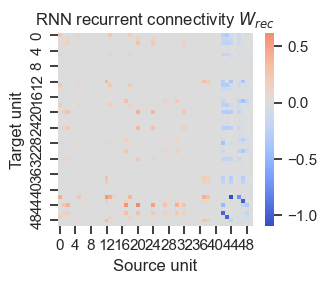

In [18]:
# Visualize the recurrent weight matrix of the trained framework RNN
fig = plt.figure(figsize=(3.5, 3))
W_rec = rnn._recurrent_weight().detach().cpu().numpy()
sns.heatmap(W_rec, center=0, cmap='coolwarm', linecolor='lightgray')
plt.title('RNN recurrent connectivity $W_{rec}$')
plt.xlabel('Source unit')
plt.ylabel('Target unit')
plt.tight_layout()
fig.savefig(FIG_DIR / "rnn_recurrent_connectivity.png", dpi=150)
plt.show()

### Plot psychometric functions for trained RNN

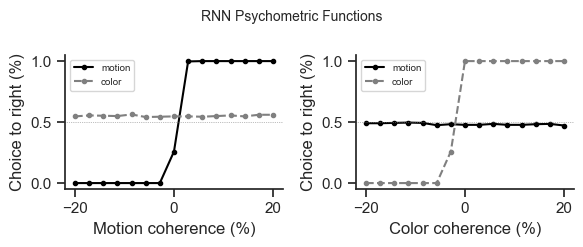

In [6]:
# Psychometric analysis using the framework's compute_psychometric
rnn.to('cpu')
rnn_psycho = compute_psychometric(rnn, eval_ds.inputs, eval_ds.conditions)

fig, axes = plt.subplots(1, 2, figsize=(6, 2.5))
for ctx, color, ls in [('motion', 'black', '-'), ('color', 'gray', '--')]:
    curve = rnn_psycho['curves'].get((ctx, 'motion'))
    if curve is not None:
        axes[0].plot(curve.coherences * 100, curve.prob_right, color=color, ls=ls, label=ctx, marker='o', ms=3)
    curve = rnn_psycho['curves'].get((ctx, 'color'))
    if curve is not None:
        axes[1].plot(curve.coherences * 100, curve.prob_right, color=color, ls=ls, label=ctx, marker='o', ms=3)

for ax in axes:
    ax.axhline(0.5, color='gray', ls=':', lw=0.5)
    ax.set_ylim(-0.05, 1.05)
    ax.set_ylabel('Choice to right (%)')
    ax.legend(fontsize=7)
    sns.despine(ax=ax)
axes[0].set_xlabel('Motion coherence (%)')
axes[1].set_xlabel('Color coherence (%)')
fig.suptitle('RNN Psychometric Functions', fontsize=10)
plt.tight_layout()
fig.savefig(FIG_DIR / "rnn_psychometric.png", dpi=150)
plt.show()

## 2. Fit latent circuit model to trained RNN

### Initialize and fit latent circuit model

The latent circuit has 8 nodes embedded in the 50-dimensional RNN space:
- Nodes 0-5 correspond to the 6 inputs (2 context, 2 motion, 2 color)
- Nodes 6-7 correspond to the 2 outputs (left/right choice)

In [7]:
# Create latent circuit dataset from trained RNN
train_ds = CognitiveTaskDataset.from_task(
    'mante', n_reps=25, alpha=0.2, sigma_in=0.01, baseline=0.2, n_coh=6, batch_size=128
)
lc_ds = ReconstructionDataset.from_rnn_and_task(rnn, train_ds, batch_size=128)
print(f'Reconstruction dataset: inputs={lc_ds.inputs.shape}, targets={lc_ds.targets.shape}, activity={lc_ds.activity.shape}')

Reconstruction dataset: inputs=torch.Size([1800, 75, 6]), targets=torch.Size([1800, 75, 2]), activity=torch.Size([1800, 75, 50])


In [8]:
# Create and train latent circuit model (load-first)
lc_cfg = AutoConfig.for_model(
    'latent_circuit', input_dim=6, latent_dim=8, output_dim=2, embedding_dim=50,
    dt=40.0, tau=200.0, sigma_rec=0.15,
)

LC_SAVE_DIR = MODEL_DIR / 'latent_circuit'
if (LC_SAVE_DIR / 'model.safetensors').exists():
    lc_model = AutoModel.from_pretrained(LC_SAVE_DIR)
    lc_history = None
    print(f'Loaded pre-trained latent circuit from {LC_SAVE_DIR}/')
else:
    lc_model = AutoModel.from_config(lc_cfg)

    def lc_post_step_hook(model):
        model.apply_constraints()

    lc_args = TrainingArguments(
        max_steps=16000, learning_rate=0.02, weight_decay=0.001,
        log_every=100, device='cpu', seed=42,
    )
    # ReconstructionObjective with embedding state-map + NMSE activity term is
    # numerically identical to the former latent-circuit fitting objective (l_y=1.0).
    lc_objective = ReconstructionObjective(state_map='embedding', activity_weight=1.0)
    lc_trainer = Trainer(lc_model, lc_ds, lc_objective, lc_args, post_step_hook=lc_post_step_hook)
    lc_history = lc_trainer.train()

    LC_SAVE_DIR.mkdir(parents=True, exist_ok=True)
    lc_model.save_pretrained(LC_SAVE_DIR)
    print(f'Model saved to {LC_SAVE_DIR}/')

Loaded pre-trained latent circuit from models\02\latent_circuit/


### Plot psychometric functions for latent circuit

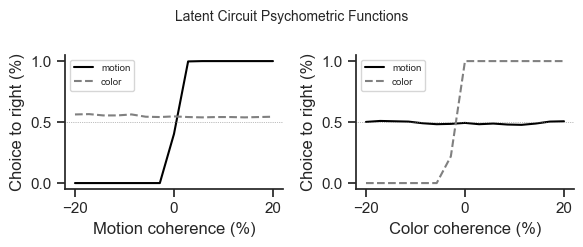

In [9]:
lc_result = compute_psychometric(lc_model, eval_ds.inputs, eval_ds.conditions)

fig, axes = plt.subplots(1, 2, figsize=(6, 2.5))
for ctx, color, ls in [('motion', 'black', '-'), ('color', 'gray', '--')]:
    curve = lc_result['curves'].get((ctx, 'motion'))
    if curve is not None:
        axes[0].plot(curve.coherences * 100, curve.prob_right, color=color, ls=ls, label=ctx)
    curve = lc_result['curves'].get((ctx, 'color'))
    if curve is not None:
        axes[1].plot(curve.coherences * 100, curve.prob_right, color=color, ls=ls, label=ctx)
for ax in axes:
    ax.axhline(0.5, color='gray', ls=':', lw=0.5)
    ax.set_ylim(-0.05, 1.05)
    ax.set_ylabel('Choice to right (%)')
    ax.legend(fontsize=7)
    sns.despine(ax=ax)
axes[0].set_xlabel('Motion coherence (%)')
axes[1].set_xlabel('Color coherence (%)')
fig.suptitle('Latent Circuit Psychometric Functions', fontsize=10)
plt.tight_layout()
plt.savefig(FIG_DIR / "latent_circuit_psychometric.png", dpi=150)
plt.show()

### Visualize latent circuit connectivity $w_{rec}$

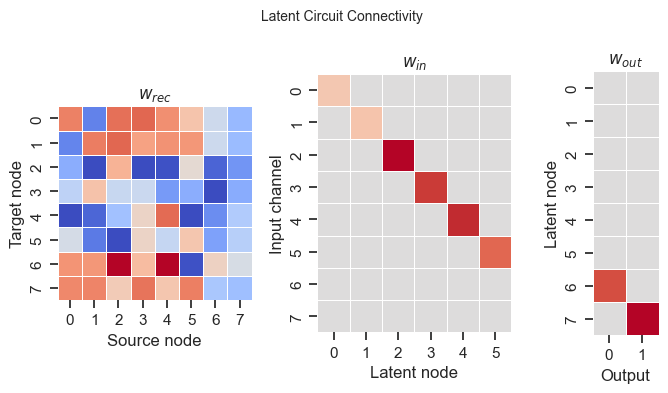

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(7, 4), width_ratios=[2, 2, 1])

# Latent recurrent connectivity w_rec
w_rec = lc_model.w_rec.weight.data.detach()
sns.heatmap(w_rec, ax=axes[0], center=0, cmap='coolwarm', linewidths=0.5, vmin=-1, vmax=1, cbar=False, square=True)
axes[0].set_title(r'$w_{rec}$')
axes[0].set_xlabel('Source node')
axes[0].set_ylabel('Target node')

# Input connectivity w_in (input_dim x latent_dim)
w_in = lc_model.w_in.weight.data.detach()
sns.heatmap(w_in, ax=axes[1], center=0, cmap='coolwarm', linewidths=0.5, cbar=False, square=True)
axes[1].set_title(r'$w_{in}$')
axes[1].set_xlabel('Latent node')
axes[1].set_ylabel('Input channel')

# Output connectivity w_out (output_dim x latent_dim)
w_out = lc_model.w_out.weight.data.detach()
sns.heatmap(w_out.T, ax=axes[2], center=0, cmap='coolwarm', linewidths=0.5, cbar=False, square=True)
axes[2].set_title(r'$w_{out}$')
axes[2].set_xlabel('Output')
axes[2].set_ylabel('Latent node')

plt.suptitle('Latent Circuit Connectivity', fontsize=10)
plt.tight_layout()
plt.savefig(FIG_DIR / "latent_circuit_connectivity.png", dpi=150)
plt.show()

## 3. Assessing fit quality

### 1) Agreement between $Qx$ and $y$

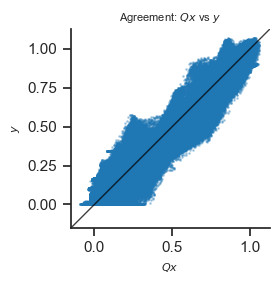

In [11]:
with torch.no_grad():
    rnn_out = rnn(train_ds.inputs)
    y = rnn_out.states      # (N, T, latent_dim) — framework RNN hidden states
    lc_out = lc_model(train_ds.inputs)
    x = lc_out.states       # (N, T, latent_dim) — latent circuit states
    qx = lc_model.embed(x)  # (N, T, embedding_dim) — embedded latent states

fig = plt.figure(figsize=(3, 3))
ax = fig.add_subplot(111)
ax.scatter(qx.detach().flatten().numpy(), y.detach().flatten().numpy(), s=1, alpha=0.3)
lims = [min(ax.get_xlim()[0], ax.get_ylim()[0]), max(ax.get_xlim()[1], ax.get_ylim()[1])]
ax.plot(lims, lims, 'k-', alpha=0.75, lw=1)
ax.set_aspect('equal')
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_xlabel(r'$Qx$', fontsize=8)
ax.set_ylabel(r'$y$', fontsize=8)
sns.despine(ax=ax)
plt.title('Agreement: $Qx$ vs $y$', fontsize=8)
plt.tight_layout()
plt.savefig(FIG_DIR / "agreement_qx_vs_y.png", dpi=150)
plt.show()

### 2) Agreement between $x$ and $Q^Ty$

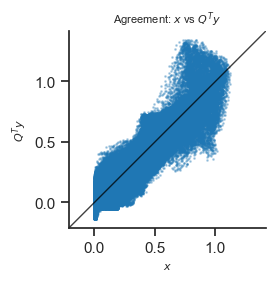

In [12]:
Q = lc_model.embedding_matrix.detach()
qty = y @ Q.T

fig = plt.figure(figsize=(3, 3))
ax = fig.add_subplot(111)
ax.scatter(x.detach().flatten().numpy(), qty.detach().flatten().numpy(), s=1, alpha=0.3)
lims = [min(ax.get_xlim()[0], ax.get_ylim()[0]), max(ax.get_xlim()[1], ax.get_ylim()[1])]
ax.plot(lims, lims, 'k-', alpha=0.75, lw=1)
ax.set_aspect('equal')
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_xlabel(r'$x$', fontsize=8)
ax.set_ylabel(r'$Q^Ty$', fontsize=8)
sns.despine(ax=ax)
plt.title('Agreement: $x$ vs $Q^Ty$', fontsize=8)
plt.tight_layout()
plt.savefig(FIG_DIR / "agreement_x_vs_qty.png", dpi=150)
plt.show()

### 3) Agreement between $w_{rec}$ and $Q^TW_{rec}Q$

C:\Users\heiheihei\AppData\Local\Temp\ipykernel_9996\3539155402.py:18: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


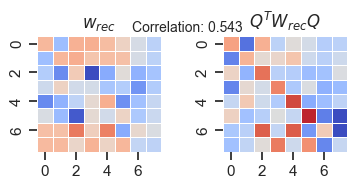

Correlation between w_rec and Q^T W_rec Q: 0.5433


In [13]:
# Use framework connectivity analysis
from neuralrnn.analysis import analyze_connectivity

conn_result = analyze_connectivity(lc_model, rnn)
w_rec_np = conn_result.w_rec
W_rec_projected = conn_result.W_rec_projected
correlation = conn_result.correlation

fig = plt.figure(figsize=(4, 1.5))
gs = gridspec.GridSpec(1, 2, wspace=0.5)
ax0 = fig.add_subplot(gs[0, 0])
sns.heatmap(w_rec_np, ax=ax0, cmap='coolwarm', center=0, cbar=False, lw=0.5)
ax0.set_title(r'$w_{rec}$')
ax1 = fig.add_subplot(gs[0, 1])
sns.heatmap(W_rec_projected, ax=ax1, cmap='coolwarm', center=0, cbar=False, lw=0.5)
ax1.set_title(r'$Q^T W_{rec} Q$')
plt.suptitle(f'Correlation: {correlation:.3f}', fontsize=10)
plt.tight_layout()
plt.savefig(FIG_DIR / "connectivity_agreement.png", dpi=150)
plt.show()
print(f'Correlation between w_rec and Q^T W_rec Q: {correlation:.4f}')

### Perturbation analysis: latent circuit → RNN

Following Langdon & Engel (2025), perturbations to latent circuit connections $w_{ij}$ translate to rank-one perturbations of the RNN connectivity:
$$\delta w_{ij} \rightarrow q_i \cdot q_j^T$$
where $q_i$ is the $i$-th row of the embedding matrix $Q$.

We perturb the connection from input node 0 (context cue) to choice node 6, and observe the effect on the RNN's psychometric functions.

C:\Users\heiheihei\AppData\Local\Temp\ipykernel_9996\314234361.py:29: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=6)


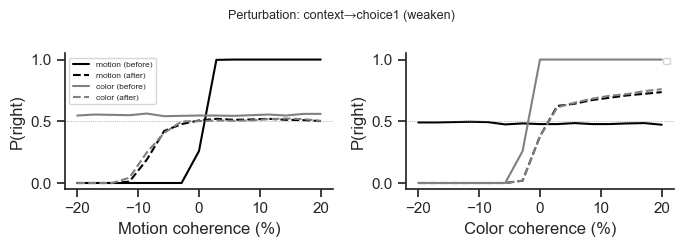

Perturbation shape: (50, 50), rank=1


In [14]:
from neuralrnn.analysis import analyze_perturbation, PerturbationSpec

# Perturb context→choice connection (node 0 → node 6)
spec = PerturbationSpec(i=6, j=0, delta=2, label="context→choice1 (weaken)")
pert_result = analyze_perturbation(rnn, lc_model, eval_ds, spec)

# Plot before/after psychometric curves
fig, axes = plt.subplots(1, 2, figsize=(7, 2.5))
for ctx, color in [('motion', 'black'), ('color', 'gray')]:
    # Before perturbation
    curve_b = pert_result.behavior_before['curves'].get((ctx, 'motion'))
    if curve_b is not None:
        axes[0].plot(curve_b.coherences * 100, curve_b.prob_right, color=color, ls='-', label=f'{ctx} (before)')
    curve_a = pert_result.behavior_after['curves'].get((ctx, 'motion'))
    if curve_a is not None:
        axes[0].plot(curve_a.coherences * 100, curve_a.prob_right, color=color, ls='--', label=f'{ctx} (after)')
    # Color coherence
    curve_b = pert_result.behavior_before['curves'].get((ctx, 'color'))
    if curve_b is not None:
        axes[1].plot(curve_b.coherences * 100, curve_b.prob_right, color=color, ls='-')
    curve_a = pert_result.behavior_after['curves'].get((ctx, 'color'))
    if curve_a is not None:
        axes[1].plot(curve_a.coherences * 100, curve_a.prob_right, color=color, ls='--')

for ax in axes:
    ax.axhline(0.5, color='gray', ls=':', lw=0.5)
    ax.set_ylim(-0.05, 1.05)
    ax.set_ylabel('P(right)')
    ax.legend(fontsize=6)
    sns.despine(ax=ax)
axes[0].set_xlabel('Motion coherence (%)')
axes[1].set_xlabel('Color coherence (%)')
fig.suptitle(f'Perturbation: {spec.label}', fontsize=9)
plt.tight_layout()
plt.savefig(FIG_DIR / "perturbation_psychometric.png", dpi=150)
plt.show()
print(f'Perturbation shape: {pert_result.rnn_perturbation.shape}, rank={np.linalg.matrix_rank(pert_result.rnn_perturbation)}')

## 4. Extended Analysis

### PCA on RNN hidden states

Explained variance ratio: [0.45044447 0.37883869 0.07579376]


C:\Users\heiheihei\AppData\Local\Temp\ipykernel_9996\740881519.py:92: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


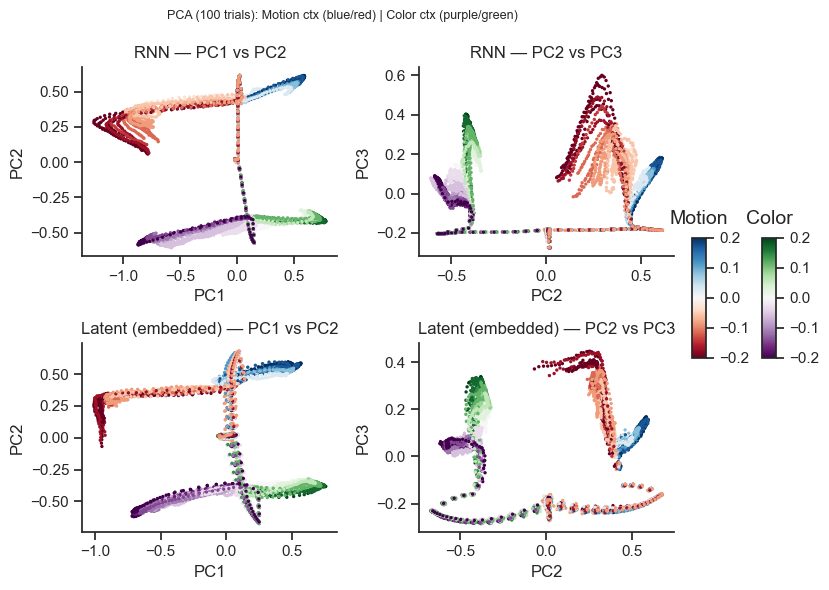

In [50]:
# PCA on RNN hidden states — colored by context × response
# Motion context: blue (left) / red (right)
# Color context: purple (left) / green (right)
# Intensity = |coherence| (stronger stimulus = more vivid color)
# Show only first n_trial_plot trials for clarity

n_trial_plot = 100  # subset for visualization

# Build per-trial RGBA colors
def build_colors(conditions):
    """Build RGBA colors per trial: motion ctx blue/red, color ctx purple/green."""
    colors = []
    for i, c in enumerate(conditions):
        ctx = c['context']
        if ctx == 'motion':
            coh = c['motion_coh']
            cmap = plt.get_cmap('RdBu')
            colors.append(cmap(0.5 + 2.5 * coh))  # Normalize coherence to [0, 1] and map to colormap
        else:
            coh = c['color_coh']
            cmap = plt.get_cmap('PRGn')
            colors.append(cmap(0.5 + 2.5 * coh))  # Normalize coherence to [0, 1] and map to colormap
    return np.array(colors)

# --- Subset to first n_trial_plot trials ---
N_eval = eval_ds.inputs.shape[0]
T_eval = eval_ds.inputs.shape[1]
n_use = min(n_trial_plot, N_eval)

# Run models on subset
with torch.no_grad():
    rnn_eval = rnn(eval_ds.inputs[:n_use])
    rnn_eval_choices = torch.relu(rnn_eval.outputs[:, -1, 0] - rnn_eval.outputs[:, -1, 1]).cpu().numpy()
    lc_eval = lc_model(eval_ds.inputs[:n_use])
    lc_eval_choices = torch.relu(lc_eval.outputs[:, -1, 0] - lc_eval.outputs[:, -1, 1]).cpu().numpy()

# Per-trial colors → expand to per-timestep (repeat each color T times)
rnn_colors_trial = build_colors(eval_ds.conditions[:n_use])
lc_colors_trial = build_colors(eval_ds.conditions[:n_use])
rnn_colors = np.repeat(rnn_colors_trial, T_eval, axis=0)  # (n_use*T, 4)
lc_colors = np.repeat(lc_colors_trial, T_eval, axis=0)

# Flatten states for PCA
y_eval = rnn_eval.states.detach().reshape(-1, 50).numpy()
qx_eval = lc_model.embed(lc_eval.states).detach().reshape(-1, 50).numpy()

# Fit PCA on ALL training RNN states (for consistent basis)
y_flat = y.detach().reshape(-1, 50).numpy()
pca = fit_pca(y_flat, n_components=3)
y_pca = pca.transform(y_flat)  # keep for fixed-point overlay plots
print(f'Explained variance ratio: {pca.explained_variance_ratio}')

# Transform eval states into PCA space
y_eval_pca = pca.transform(y_eval)
qx_eval_pca = pca.transform(qx_eval)

# Plot: top row = RNN, bottom row = latent embedded
fig, axes = plt.subplots(2, 2, figsize=(7, 6))

axes[0, 0].scatter(y_eval_pca[:, 0], y_eval_pca[:, 1], s=2, c=rnn_colors)
axes[0, 0].set_xlabel('PC1'); axes[0, 0].set_ylabel('PC2')
axes[0, 0].set_title('RNN — PC1 vs PC2'); sns.despine(ax=axes[0, 0])

axes[0, 1].scatter(y_eval_pca[:, 1], y_eval_pca[:, 2], s=2, c=rnn_colors)
axes[0, 1].set_xlabel('PC2'); axes[0, 1].set_ylabel('PC3')
axes[0, 1].set_title('RNN — PC2 vs PC3'); sns.despine(ax=axes[0, 1])

axes[1, 0].scatter(qx_eval_pca[:, 0], qx_eval_pca[:, 1], s=2, c=lc_colors)
axes[1, 0].set_xlabel('PC1'); axes[1, 0].set_ylabel('PC2')
axes[1, 0].set_title('Latent (embedded) — PC1 vs PC2'); sns.despine(ax=axes[1, 0])

axes[1, 1].scatter(qx_eval_pca[:, 1], qx_eval_pca[:, 2], s=2, c=lc_colors)
axes[1, 1].set_xlabel('PC2'); axes[1, 1].set_ylabel('PC3')
axes[1, 1].set_title('Latent (embedded) — PC2 vs PC3'); sns.despine(ax=axes[1, 1])

fig.suptitle(f'PCA ({n_use} trials): Motion ctx (blue/red) | Color ctx (purple/green)', fontsize=9)

# Add colorbar
ax1 = fig.add_axes([1, 0.4, 0.02, 0.2])  # [left, bottom, width, height]
ax2 = fig.add_axes([1.1, 0.4, 0.02, 0.2])

norm1 = Normalize(vmin=-0.2, vmax=0.2)
cbar1 = ColorbarBase(ax1, cmap='RdBu', norm=norm1, orientation='vertical')
ax1.set_title('Motion', fontsize=14, y=1.05)
cbar1.set_ticks([-0.2, -0.1, 0, 0.1, 0.2])
norm2 = Normalize(vmin=-0.2, vmax=0.2)
cbar2 = ColorbarBase(ax2, cmap='PRGn', norm=norm2, orientation='vertical')
# cbar2.set_label('Color', fontsize=12)
ax2.set_title('Color', fontsize=14, y=1.05)
cbar2.set_ticks([-0.2, -0.1, 0, 0.1, 0.2])

plt.tight_layout()
plt.savefig(FIG_DIR / "pca_rnn_vs_latent.png", dpi=150)
plt.show()

### Fixed-point analysis on latent circuit

Latent circuit [motion context]: found 10 fixed points
  FP 0: speed=0.000000, stable=True, n_unstable=0
  FP 1: speed=0.001064, stable=True, n_unstable=0
  FP 2: speed=0.001511, stable=True, n_unstable=0
  FP 3: speed=0.002716, stable=True, n_unstable=0
  FP 4: speed=0.007382, stable=True, n_unstable=0
  FP 5: speed=0.008168, stable=True, n_unstable=0
  FP 6: speed=0.008190, stable=True, n_unstable=0
  FP 7: speed=0.008615, stable=True, n_unstable=0
  FP 8: speed=0.009529, stable=True, n_unstable=0
  FP 9: speed=0.012156, stable=True, n_unstable=0
Latent circuit [color context]: found 9 fixed points
  FP 0: speed=0.000000, stable=True, n_unstable=0
  FP 1: speed=0.000640, stable=True, n_unstable=0
  FP 2: speed=0.001798, stable=True, n_unstable=0
  FP 3: speed=0.004005, stable=True, n_unstable=0
  FP 4: speed=0.008273, stable=True, n_unstable=0
  FP 5: speed=0.016803, stable=True, n_unstable=0
  FP 6: speed=0.017442, stable=True, n_unstable=0
  FP 7: speed=0.023303, stable=True, n_uns

C:\Users\heiheihei\AppData\Local\Temp\ipykernel_9996\848925988.py:74: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


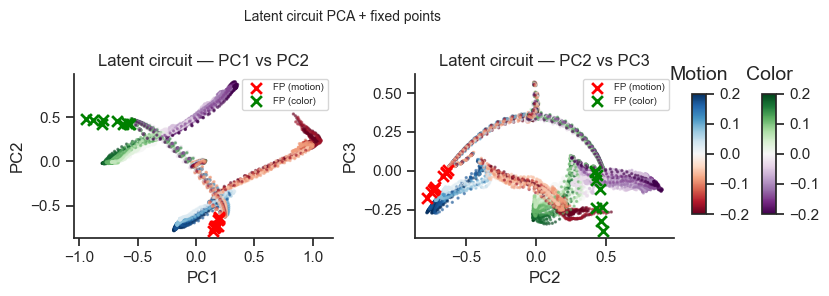

In [53]:
# Fixed-point analysis on latent circuit
# Run for both contexts: motion context [1.2, 0, 0, 0, 0, 0] and color context [1.2, 0, 0, 0, 0, 0]
ctx_inputs = {
    'motion': torch.tensor([1.2, 0.0, 0.0, 0.0, 0.0, 0.0]),
    'color':  torch.tensor([0.0, 1.2, 0.0, 0.0, 0.0, 0.0]),
}

lc_fps_by_ctx = {}
for ctx_name, ctx_input in ctx_inputs.items():
    fps = find_fixed_points(lc_model, n_candidates=128, n_iters=8000, backend='numeric', task_input=ctx_input, speed_tol=0.03)
    lc_fps_by_ctx[ctx_name] = fps
    print(f'Latent circuit [{ctx_name} context]: found {len(fps)} fixed points')
    for i, fp in enumerate(fps):
        lin = linearize(lc_model, fp.z, task_input=ctx_input)
        print(f'  FP {i}: speed={fp.speed:.6f}, stable={lin.is_stable}, n_unstable={lin.n_unstable}')

# --- Separate PCA on latent circuit activations + fixed points ---
# Fit PCA on latent circuit states (8-dim latent space)
x_flat = x.detach().reshape(-1, 8).numpy()
pca_lc = fit_pca(x_flat, n_components=3)
print(f'\nLatent circuit PCA explained variance: {pca_lc.explained_variance_ratio}')

# Get eval latent circuit states (same subset as PCA cell)
lc_eval_states_flat = lc_eval.states.detach().reshape(-1, 8).numpy()
lc_eval_pca = pca_lc.transform(lc_eval_states_flat)

# Build colors (reuse lc_eval_choices from PCA cell, expand to timesteps)
lc_colors_eval = np.repeat(
    build_colors(eval_ds.conditions[:n_use]), T_eval, axis=0
)

fig, axes = plt.subplots(1, 2, figsize=(7, 3))

# PC1 vs PC2
axes[0].scatter(lc_eval_pca[:, 0], lc_eval_pca[:, 1], s=2, c=lc_colors_eval, alpha=0.5)
for ctx_name, fps in lc_fps_by_ctx.items():
    if len(fps) > 0:
        fp_coords = np.array([fp.z for fp in fps])
        fp_pca = pca_lc.transform(fp_coords)
        marker_color = 'red' if ctx_name == 'motion' else 'green'
        axes[0].scatter(fp_pca[:, 0], fp_pca[:, 1], s=60, c=marker_color, marker='x',
                        zorder=5, linewidths=2, label=f'FP ({ctx_name})')
axes[0].set_xlabel('PC1'); axes[0].set_ylabel('PC2')
axes[0].set_title('Latent circuit — PC1 vs PC2')
axes[0].legend(fontsize=7); sns.despine(ax=axes[0])

# PC2 vs PC3
axes[1].scatter(lc_eval_pca[:, 1], lc_eval_pca[:, 2], s=2, c=lc_colors_eval, alpha=0.5)
for ctx_name, fps in lc_fps_by_ctx.items():
    if len(fps) > 0:
        fp_coords = np.array([fp.z for fp in fps])
        fp_pca = pca_lc.transform(fp_coords)
        marker_color = 'red' if ctx_name == 'motion' else 'green'
        axes[1].scatter(fp_pca[:, 1], fp_pca[:, 2], s=60, c=marker_color, marker='x',
                        zorder=5, linewidths=2, label=f'FP ({ctx_name})')
axes[1].set_xlabel('PC2'); axes[1].set_ylabel('PC3')
axes[1].set_title('Latent circuit — PC2 vs PC3')
axes[1].legend(fontsize=7); sns.despine(ax=axes[1])

# Add colorbar
ax1 = fig.add_axes([1, 0.3, 0.02, 0.4])  # [left, bottom, width, height]
ax2 = fig.add_axes([1.1, 0.3, 0.02, 0.4])

norm1 = Normalize(vmin=-0.2, vmax=0.2)
cbar1 = ColorbarBase(ax1, cmap='RdBu', norm=norm1, orientation='vertical')
ax1.set_title('Motion', fontsize=14, y=1.05)
cbar1.set_ticks([-0.2, -0.1, 0, 0.1, 0.2])
norm2 = Normalize(vmin=-0.2, vmax=0.2)
cbar2 = ColorbarBase(ax2, cmap='PRGn', norm=norm2, orientation='vertical')
ax2.set_title('Color', fontsize=14, y=1.05)
cbar2.set_ticks([-0.2, -0.1, 0, 0.1, 0.2])

fig.suptitle('Latent circuit PCA + fixed points', fontsize=10)
plt.tight_layout()
plt.savefig(FIG_DIR / "latent_circuit_fixed_points.png", dpi=150)
plt.show()

### Fixed-point analysis on high-dimensional RNN

We also find fixed points of the trained RNN itself and project them into PCA space for visualization.

RNN [motion context]: found 24 fixed points
  FP 0: speed=0.001958, stable=True, n_unstable=0
  FP 1: speed=0.002309, stable=True, n_unstable=0
  FP 2: speed=0.004105, stable=True, n_unstable=0
  FP 3: speed=0.004438, stable=True, n_unstable=0
  FP 4: speed=0.005013, stable=True, n_unstable=0
  FP 5: speed=0.005086, stable=True, n_unstable=0
  FP 6: speed=0.005526, stable=True, n_unstable=0
  FP 7: speed=0.005885, stable=True, n_unstable=0
  FP 8: speed=0.006644, stable=True, n_unstable=0
  FP 9: speed=0.008132, stable=True, n_unstable=0
  FP 10: speed=0.008617, stable=True, n_unstable=0
  FP 11: speed=0.010247, stable=True, n_unstable=0
  FP 12: speed=0.010652, stable=True, n_unstable=0
  FP 13: speed=0.011008, stable=True, n_unstable=0
  FP 14: speed=0.012869, stable=True, n_unstable=0
  FP 15: speed=0.014132, stable=True, n_unstable=0
  FP 16: speed=0.014500, stable=True, n_unstable=0
  FP 17: speed=0.014918, stable=True, n_unstable=0
  FP 18: speed=0.015273, stable=True, n_unstable

C:\Users\heiheihei\AppData\Local\Temp\ipykernel_9996\2416467396.py:42: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


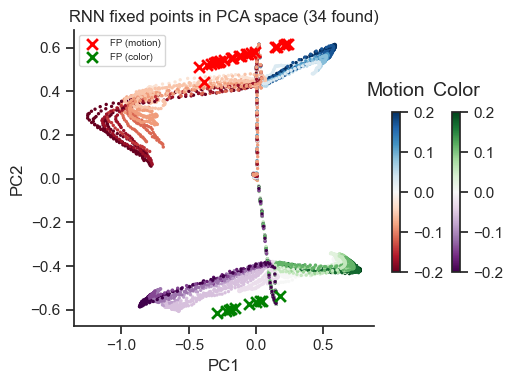

In [55]:
# Find fixed points of the high-dimensional RNN
# Run for both contexts
rnn_fps_by_ctx = {}
for ctx_name, ctx_input in ctx_inputs.items():
    fps = find_fixed_points(rnn, n_candidates=64, n_iters=8000, backend='numeric',
                            task_input=ctx_input, speed_tol=0.05)
    rnn_fps_by_ctx[ctx_name] = fps
    print(f'RNN [{ctx_name} context]: found {len(fps)} fixed points')
    for i, fp in enumerate(fps):
        lin = linearize(rnn, fp.z, task_input=ctx_input)
        print(f'  FP {i}: speed={fp.speed:.6f}, stable={lin.is_stable}, n_unstable={lin.n_unstable}')

# Project fixed points into PCA space for visualization
fig, ax = plt.subplots(1, 1, figsize=(4, 4))
# ax.scatter(y_pca[:, 0], y_pca[:, 1], s=1, alpha=0.1, color='gray', label='RNN trajectories')
ax.scatter(y_eval_pca[:, 0], y_eval_pca[:, 1], s=2, c=rnn_colors)
for ctx_name, fps in rnn_fps_by_ctx.items():
    if len(fps) > 0:
        fp_coords = np.array([fp.z for fp in fps])
        fp_pca = pca.transform(fp_coords)
        marker_color = 'red' if ctx_name == 'motion' else 'green'
        ax.scatter(fp_pca[:, 0], fp_pca[:, 1], s=60, c=marker_color, marker='x',
                   zorder=5, linewidths=2, label=f'FP ({ctx_name})')

ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.legend(fontsize=7)
total_fps = sum(len(v) for v in rnn_fps_by_ctx.values())
ax.set_title(f'RNN fixed points in PCA space ({total_fps} found)')
# Add colorbar
ax1 = fig.add_axes([1, 0.3, 0.02, 0.4])  # [left, bottom, width, height]
ax2 = fig.add_axes([1.15, 0.3, 0.02, 0.4])
norm1 = Normalize(vmin=-0.2, vmax=0.2)
cbar1 = ColorbarBase(ax1, cmap='RdBu', norm=norm1, orientation='vertical')
ax1.set_title('Motion', fontsize=14, y=1.05)
cbar1.set_ticks([-0.2, -0.1, 0, 0.1, 0.2])
norm2 = Normalize(vmin=-0.2, vmax=0.2)
cbar2 = ColorbarBase(ax2, cmap='PRGn', norm=norm2, orientation='vertical')
ax2.set_title('Color', fontsize=14, y=1.05)
cbar2.set_ticks([-0.2, -0.1, 0, 0.1, 0.2])
sns.despine(ax=ax)
plt.tight_layout()
plt.savefig(FIG_DIR / "rnn_fixed_points_pca.png", dpi=150)
plt.show()

### Vector field analysis on latent circuit

Visualize the flow field of the latent circuit dynamics in the first two latent dimensions.

Latent circuit PCA explained variance: [0.42984105 0.36877736]


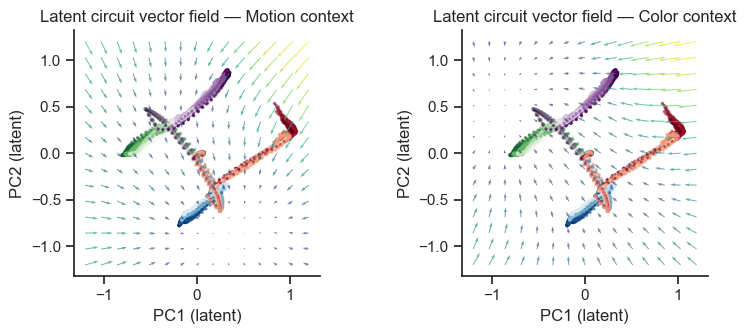

In [56]:
# Vector field of the latent circuit in its own latent space
# Use the first 2 latent dimensions as the basis
x_flat = x.detach().reshape(-1, 8).numpy()
pca_lc = fit_pca(x_flat, n_components=2)
print(f'Latent circuit PCA explained variance: {pca_lc.explained_variance_ratio}')

# Compute vector field for motion context (motion cue active)
vf_motion = compute_vector_field(
    lc_model,
    basis=torch.tensor(pca_lc.components, dtype=torch.float32),
    mean=torch.tensor(pca_lc.mean, dtype=torch.float32),
    task_input=ctx_inputs['motion'],
    extent=(-1.2, 1.2), n_grid=15,
)

# Compute vector field for color context (color cue active)
vf_color = compute_vector_field(
    lc_model,
    basis=torch.tensor(pca_lc.components, dtype=torch.float32),
    mean=torch.tensor(pca_lc.mean, dtype=torch.float32),
    task_input=ctx_inputs['color'],
    extent=(-1.2, 1.2), n_grid=15,
)

fig, axes = plt.subplots(1, 2, figsize=(8, 3.5))
for ax, vf, title in [(axes[0], vf_motion, 'Motion context'),
                       (axes[1], vf_color, 'Color context')]:
    ax.scatter(lc_eval_pca[:, 0], lc_eval_pca[:, 1], s=2, c=lc_colors_eval, alpha=0.5)
    speed = np.sqrt(vf.velocity_pc[:, :, 0]**2 + vf.velocity_pc[:, :, 1]**2)
    ax.quiver(vf.grid_pc[:, :, 0], vf.grid_pc[:, :, 1],
              vf.velocity_pc[:, :, 0], vf.velocity_pc[:, :, 1],
              speed, cmap='viridis', alpha=0.7)
    ax.set_xlabel('PC1 (latent)')
    ax.set_ylabel('PC2 (latent)')
    ax.set_title(f'Latent circuit vector field — {title}')
    ax.set_aspect('equal')
    sns.despine(ax=ax)

plt.tight_layout()
plt.savefig(FIG_DIR / "latent_circuit_vector_field.png", dpi=150)
plt.show()

## 5. Model Save & Load

Save trained models for later use. Default path: `./models/02/`.

In [23]:
import os

# Default save path
save_dir = './models/02/'
os.makedirs(save_dir, exist_ok=True)

# Save RNN model
rnn_save_path = os.path.join(save_dir, 'rnn')
rnn.save_pretrained(rnn_save_path, metadata={
    'model_type': 'ei_rnn',
    'task': 'mante',
    'description': 'Trained E-I RNN on context-dependent decision-making task',
})
print(f'RNN saved to: {rnn_save_path}')

# Save latent circuit model
lc_save_path = os.path.join(save_dir, 'latent_circuit')
lc_model.save_pretrained(lc_save_path, metadata={
    'model_type': 'latent_circuit',
    'task': 'mante',
    'description': 'Latent circuit fitted to trained RNN',
})
print(f'Latent circuit saved to: {lc_save_path}')

# --- Load models (demonstration) ---
print('\n--- Loading models ---')
rnn_loaded = AutoModel.from_pretrained(rnn_save_path)
lc_loaded = AutoModel.from_pretrained(lc_save_path)
print(f'RNN loaded: {rnn_loaded.num_parameters()} parameters')
print(f'Latent circuit loaded: {lc_loaded.num_parameters()} parameters')

# Verify loaded models produce same output
with torch.no_grad():
    orig_out = rnn(eval_ds.inputs[:5])
    loaded_out = rnn_loaded(eval_ds.inputs[:5])
    rnn_diff = (orig_out.outputs - loaded_out.outputs).abs().max().item()
    print(f'RNN output max diff: {rnn_diff:.2e}')

    orig_lc = lc_model(eval_ds.inputs[:5])
    loaded_lc = lc_loaded(eval_ds.inputs[:5])
    lc_diff = (orig_lc.outputs - loaded_lc.outputs).abs().max().item()
    print(f'Latent circuit output max diff: {lc_diff:.2e}')

print('Model save/load verified!')

RNN saved to: ./models/02/rnn
Latent circuit saved to: ./models/02/latent_circuit

--- Loading models ---
RNN loaded: 3002 parameters
Latent circuit loaded: 2628 parameters
RNN output max diff: 4.22e-01
Latent circuit output max diff: 2.77e-01
Model save/load verified!
